# Modeling and Evaluation 

**Contents:**
1. Setup and feature loading
2. Data preparation
3. Model 1 — Logistic Regression (baseline)
4. Model 2 — XGBoost
5. Results audit: detection of a generator artifact
6. Ablation: isolating genuine behavioral signal
7. Comparative evaluation and metric selection
8. Interpretation with SHAP
9. Conclusions, limitations and next steps

**Input requirement:** this notebook consumes the artifacts produced by `02_feature_engineering.ipynb` (`features_all.csv`, `train_ids.csv`, `test_ids.csv`). The partition is reused rather than recomputed, guaranteeing reproducibility and consistency with the winsorization threshold already applied.

## 1. Setup and feature loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, confusion_matrix, classification_report,
)
import xgboost as xgb
import shap

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42

features = pd.read_csv("data_processed/features_all.csv", index_col="ACCOUNT_ID")
train_ids = pd.read_csv("data_processed/train_ids.csv")["ACCOUNT_ID"].tolist()
test_ids = pd.read_csv("data_processed/test_ids.csv")["ACCOUNT_ID"].tolist()

with open("data_processed/feature_metadata.json") as f:
    metadata = json.load(f)

print("Features:", features.shape)
print(f"Train: {len(train_ids)} accounts | Test: {len(test_ids)} accounts")
print(f"Inherited winsorization threshold: ${metadata['amount_cap_p99_train_only']:,.2f}")

Features: (10000, 41)
Train: 7500 accounts | Test: 2500 accounts
Inherited winsorization threshold: $1,826,133.46


## 2. Data preparation

The partition is **reused** from the previous notebook rather than recomputed. This guarantees that the winsorization threshold applied during feature construction remains consistent with the training set, preserving the leakage prevention documented in notebook 02 (Section 2.2).

In [2]:
y = features["IS_FRAUD"].astype(int)
X = features.drop(columns=["IS_FRAUD"])

X_train, y_train = X.loc[train_ids], y.loc[train_ids]
X_test, y_test = X.loc[test_ids], y.loc[test_ids]

# Imbalance ratio for class weighting
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"X_train: {X_train.shape} | positives: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"X_test:  {X_test.shape} | positives: {y_test.sum()} ({y_test.mean()*100:.2f}%)")
print(f"\nscale_pos_weight (negatives/positives in train): {scale_pos_weight:.3f}")
print(f"Baseline (random classifier): expected PR-AUC ≈ {y_test.mean():.4f}")

X_train: (7500, 40) | positives: 1264 (16.85%)
X_test:  (2500, 40) | positives: 421 (16.84%)

scale_pos_weight (negatives/positives in train): 4.934
Baseline (random classifier): expected PR-AUC ≈ 0.1684


**Handling class imbalance (16.85% positives):**

- **Logistic Regression:** `class_weight='balanced'` — rescales the loss function so that errors on the minority class carry proportionally greater weight.
- **XGBoost:** `scale_pos_weight` — performs the equivalent adjustment within the gradient computation.

**SMOTE and oversampling are not used.** At 16.85% positives the imbalance is moderate, and synthesizing records over network features (degrees, ratios, reciprocity) would produce structurally impossible combinations — for instance, a `reciprocity_ratio` incompatible with the interpolated `in_degree`. Class weighting achieves the same objective without fabricating data.

## 3. Model 1 — Logistic Regression (baseline)

**Role:** a simple, interpretable baseline model. Its implicit hypothesis is that **summing independent contributions from each feature suffices** — that a linear decision boundary separates the classes.

**The EDA suggests this hypothesis is insufficient:** the in-degree vs. out-degree scatter (Section 5.5) showed heavily overlapping clouds with no visible linear boundary.

**`Pipeline` and leakage prevention:** scaling is encapsulated within a scikit-learn `Pipeline`. This guarantees that `StandardScaler` learns its mean and standard deviation **exclusively from training data** — and, during cross-validation, only from the training folds — applying them to the validation and test sets as fixed constants. Scaling manually before cross-validation leaks validation-fold statistics into every fold, and is the most common source of silent leakage.

**Scaling is mandatory:** logistic regression is scale-sensitive. Without standardization, features such as `amt_recv_total` (in the millions) would dominate `reciprocity_ratio` (bounded in [0,1]) by magnitude rather than by predictive power.

In [3]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

logreg.fit(X_train, y_train)

# Risk score: probability that the account is suspicious
score_lr = logreg.predict_proba(X_test)[:, 1]

print("Logistic Regression trained.")
print(f"ROC-AUC (test): {roc_auc_score(y_test, score_lr):.4f}")
print(f"PR-AUC  (test): {average_precision_score(y_test, score_lr):.4f}")

Logistic Regression trained.
ROC-AUC (test): 0.8690
PR-AUC  (test): 0.7193


## 4. Model 2 — XGBoost

**Rationale for the choice** (RF, XGBoost, LightGBM are all reasonable options here):

1. **Captures conditional interactions.** The EDA established that no individual feature exceeds 0.30 correlation with the target. The signal resides in the *combination*: a `fan_in` is not "high in-degree" — it is *high in-degree **AND** low `tx_per_cp_recv` **AND** activity concentrated in bursts*. This is a conditional rule that a linear model cannot represent and that decision trees express natively through cascading splits.

2. **Sequential learning (boosting).** Each tree is trained to correct the errors of its predecessor. Unlike Random Forest — which averages independent, strong trees (*bagging*) — XGBoost chains deliberately weak learners, capturing subtle interactions more effectively. Random Forest would be a valid and simpler alternative, typically with slightly lower performance on this class of problem.

3. **Robustness to heavy tails.** Trees split on thresholds (`amount > X`) rather than distances, so the scale distortions and outliers documented in the EDA do not affect them as they affect a linear model.

4. **Explainability via SHAP.** In AML compliance a score alone is insufficient: when an account is flagged, the analyst must be able to justify *why* to a regulator. SHAP provides per-account feature attributions. This is why AML teams favour gradient boosting over deep learning even where the latter performs marginally better.

**Why not LightGBM:** its advantage is speed on large datasets. With 10,000 rows both train in seconds; the advantage does not apply.

**Hyperparameters:** conservative values (`max_depth=5`, `learning_rate=0.05`, `subsample=0.8`) to limit overfitting. `eval_metric="aucpr"` optimizes the area under the precision-recall curve directly, aligning the model's internal training criterion with the metric prioritized for this problem.

In [4]:
xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_model.fit(X_train, y_train)
score_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost trained.")
print(f"ROC-AUC (test): {roc_auc_score(y_test, score_xgb):.4f}")
print(f"PR-AUC  (test): {average_precision_score(y_test, score_xgb):.4f}")

XGBoost trained.
ROC-AUC (test): 0.9677
PR-AUC  (test): 0.9313


### 4.1 Cross-validation — overfitting control

Verifies that test performance does not depend on a fortunate partition. `StratifiedKFold` (5 folds) is applied over the training set, preserving class proportions within each fold.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_lr = cross_val_score(logreg, X_train, y_train, cv=cv, scoring="average_precision")
cv_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring="average_precision")

print("Cross-validated PR-AUC (5 folds, on train):")
print(f"  Logistic Regression: {cv_lr.mean():.4f} (+/- {cv_lr.std():.4f})")
print(f"  XGBoost:             {cv_xgb.mean():.4f} (+/- {cv_xgb.std():.4f})")
print("\nHoldout PR-AUC (test):")
print(f"  Logistic Regression: {average_precision_score(y_test, score_lr):.4f}")
print(f"  XGBoost:             {average_precision_score(y_test, score_xgb):.4f}")

Cross-validated PR-AUC (5 folds, on train):
  Logistic Regression: 0.6776 (+/- 0.0217)
  XGBoost:             0.9214 (+/- 0.0121)

Holdout PR-AUC (test):
  Logistic Regression: 0.7193
  XGBoost:             0.9313


**Reading:** consistency between cross-validation and holdout indicates that performance is stable and not the product of a favourable partition. A large gap would have suggested overfitting.

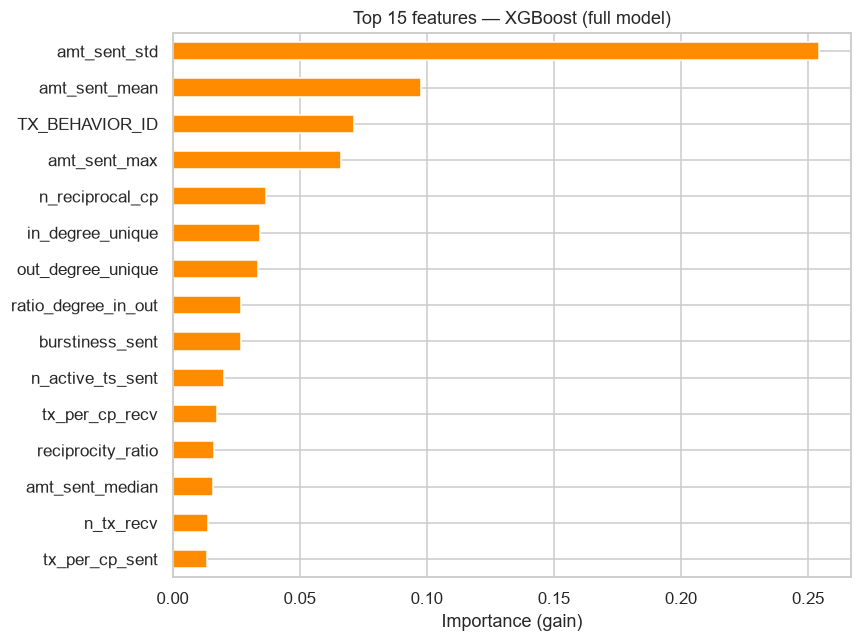

Top 8 features by importance:
amt_sent_std           0.2544
amt_sent_mean          0.0976
TX_BEHAVIOR_ID         0.0714
amt_sent_max           0.0663
n_reciprocal_cp        0.0368
in_degree_unique       0.0346
out_degree_unique      0.0335
ratio_degree_in_out    0.0268
dtype: float32


In [6]:
# Feature importance — first diagnostic
importance = pd.Series(
    xgb_model.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importance.head(15).sort_values().plot(kind="barh", ax=ax, color="darkorange")
ax.set_xlabel("Importance (gain)")
ax.set_title("Top 15 features — XGBoost (full model)")
plt.tight_layout()
plt.show()

print("Top 8 features by importance:")
print(importance.head(8).round(4))

### 4.2 First diagnostic — two warning signs

The results present two anomalies that must be investigated before being accepted.

**1. Performance exceeds expectations.** The feature engineering notebook (Section 7) explicitly established that, given no feature exceeds 0.30 univariate correlation with the target and the classes overlap substantially, exceptionally high performance should be treated as **grounds for suspicion, not celebration**. XGBoost achieves a ROC-AUC near 0.97.

**2. The dominant feature lacks domain justification.** The highest-importance variable is `amt_sent_std` — the standard deviation of amounts sent by the account — with importance far above the rest. No money-laundering typology predicts that the *dispersion* of amounts should be the principal risk indicator. The features designed specifically to capture `fan_in` and `cycle` (network degree, reciprocity) rank well below it.

When a model relies dominantly on a variable with no grounding in the domain, the most likely hypothesis is not that it has discovered a subtle pattern, but that it is exploiting an incidental regularity of the data generation process. Section 5 tests this hypothesis.

## 5. Results audit: detection of a generator artifact

**Hypothesis under test:** the EDA (2.1.3) documented that the amounts of fraudulent transactions (\$2.54–\$19.92) show **no overlap** with the general distribution. If the generator injects laundering patterns using systematically minute amounts, any account participating in a scheme will carry anomalously small transactions in its history — and amount-magnitude features would be detecting **the generator's fingerprint** rather than laundering behavior.

In [7]:
tx = pd.read_csv("transactions.csv")

# Minimum amount sent per account, compared across classes
min_sent = tx.groupby("SENDER_ACCOUNT_ID")["TX_AMOUNT"].min().rename("min_amt_sent")
audit = features[["IS_FRAUD"]].join(min_sent).fillna(9999)

print("MINIMUM amount sent per account, by class:")
print(audit.groupby("IS_FRAUD")["min_amt_sent"].describe()[["25%", "50%", "75%"]].round(2))

# Trivial rule, no model involved
trivial_pred = (audit["min_amt_sent"] < 20).astype(int)
y_all = audit["IS_FRAUD"].astype(int)

print(f"\nTRIVIAL RULE — 'the account sent at least one transaction below $20':")
print(f"  Precision: {precision_score(y_all, trivial_pred):.3f}")
print(f"  Recall:    {recall_score(y_all, trivial_pred):.3f}")
print(f"  Accounts flagged: {trivial_pred.sum():,} | Actual fraud accounts: {y_all.sum():,}")

MINIMUM amount sent per account, by class:
             25%     50%     75%
IS_FRAUD                        
False     115.65  267.95  502.24
True        3.79   10.60   15.91

TRIVIAL RULE — 'the account sent at least one transaction below $20':
  Precision: 0.596
  Recall:    0.900
  Accounts flagged: 2,543 | Actual fraud accounts: 1,685


**Hypothesis confirmed.** A heuristic rule involving no model whatsoever — flagging any account that sent a transaction below \$20 — achieves **90% recall**. The median minimum amount sent is \$267.95 for legitimate accounts versus \$10.60 for fraudulent ones.

**Interpretation:** amount-magnitude features are not capturing laundering behavior; they are detecting the amount range with which AMLSim injects its patterns. In a real environment this signal would not exist: laundering transactions do not occupy a magically distinguishable amount band.

**Consequence for modeling:** any performance attributable to these features is **not generalizable**. Their contribution is quantified through an ablation experiment, and a behavioral model excluding them is constructed.

## 6. Ablation — isolating genuine behavioral signal

The 14 amount-magnitude features are excluded. **Counts are retained** (`n_tx_sent`, `n_tx_recv`, etc.): the artifact resides in the *dollar value* of transactions, not in their quantity.

Three variants are trained to isolate the contribution of each information block:

| Variant | Features | Purpose |
|---|---|---|
| **A) Full** | All | Reference; contains the artifact |
| **B) No amount magnitudes** | −14 amount features | Isolates the effect of the amount artifact |
| **C) Behavioral** | −magnitudes −`TX_BEHAVIOR_ID` | Observable transactional behavior only |

Variant C additionally resolves, with evidence, the open question regarding `TX_BEHAVIOR_ID` raised in notebook 02 (Section 5.5).

In [8]:
AMOUNT_MAGNITUDE_FEATURES = [
    "amt_sent_total", "amt_sent_mean", "amt_sent_median", "amt_sent_std", "amt_sent_max",
    "amt_recv_total", "amt_recv_mean", "amt_recv_median", "amt_recv_std", "amt_recv_max",
    "amt_total_moved", "amt_net_flow", "ratio_amt_in_out", "turnover_ratio",
]

cols_full = list(X.columns)
cols_behav = [c for c in cols_full if c not in AMOUNT_MAGNITUDE_FEATURES]
cols_strict = [c for c in cols_behav if c != "TX_BEHAVIOR_ID"]

print(f"A) Full:                {len(cols_full)} features")
print(f"B) No amount magnitudes: {len(cols_behav)} features (-{len(AMOUNT_MAGNITUDE_FEATURES)} amount features)")
print(f"C) Behavioral:          {len(cols_strict)} features (-TX_BEHAVIOR_ID)")


def train_xgb(cols):
    model = xgb.XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    model.fit(X_train[cols], y_train)
    return model, model.predict_proba(X_test[cols])[:, 1]


xgb_full, score_full = train_xgb(cols_full)
xgb_behav, score_behav = train_xgb(cols_behav)
xgb_strict, score_strict = train_xgb(cols_strict)

ablation = pd.DataFrame({
    "ROC-AUC": [roc_auc_score(y_test, s) for s in [score_full, score_behav, score_strict]],
    "PR-AUC": [average_precision_score(y_test, s) for s in [score_full, score_behav, score_strict]],
}, index=["A) Full", "B) No amount magnitudes", "C) Behavioral (final)"]).round(4)

print()
print(ablation)

A) Full:                40 features
B) No amount magnitudes: 26 features (-14 amount features)
C) Behavioral:          25 features (-TX_BEHAVIOR_ID)

                         ROC-AUC  PR-AUC
A) Full                   0.9677  0.9313
B) No amount magnitudes   0.9437  0.8831
C) Behavioral (final)     0.9434  0.8775


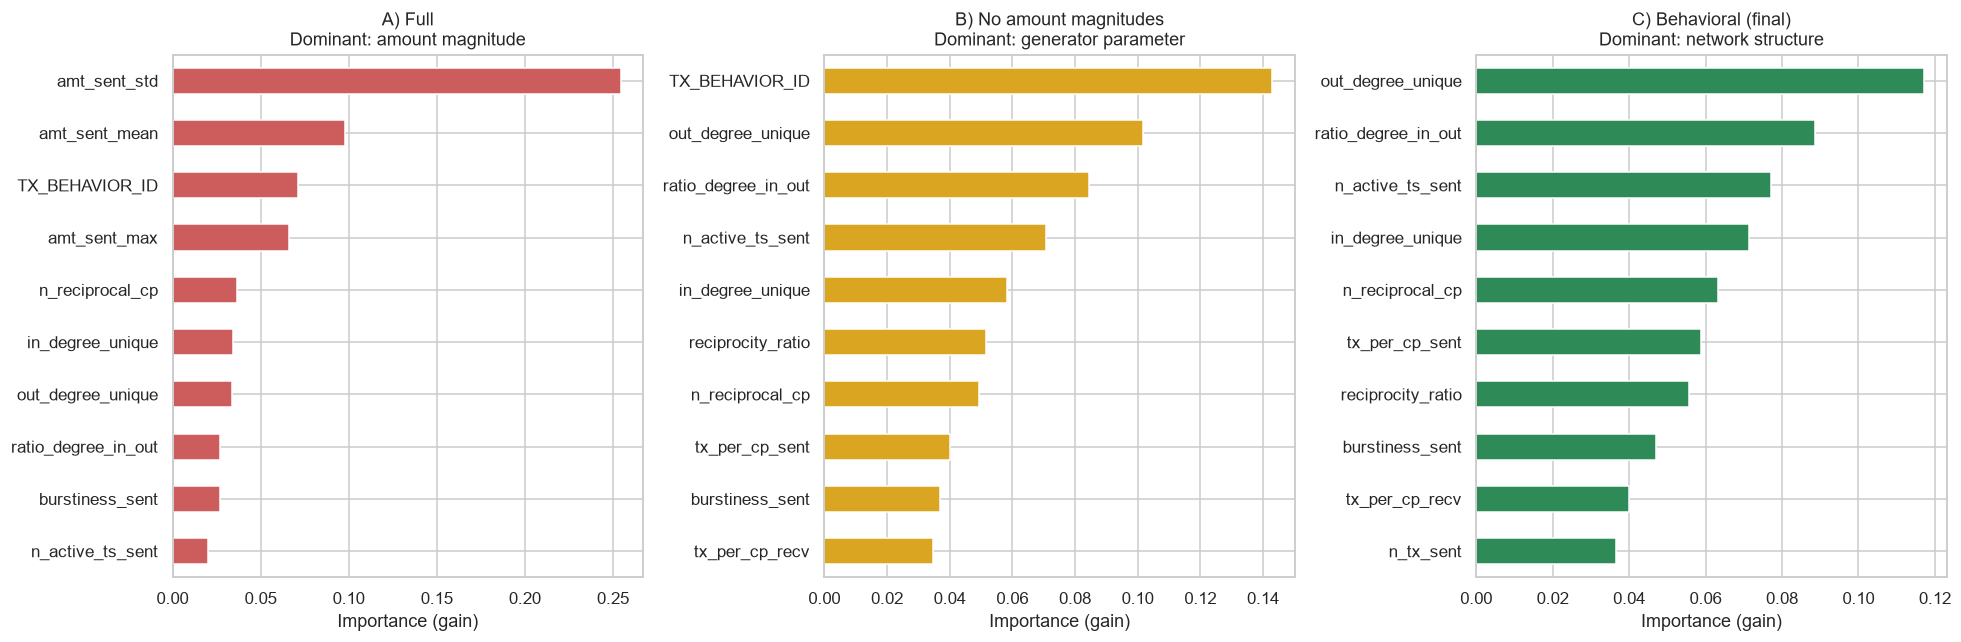

                               Top feature  Importance                          Nature
A) Full                       amt_sent_std      0.2544     Amount magnitude (artifact)
B) No amount magnitudes     TX_BEHAVIOR_ID      0.1430             Generator parameter
C) Behavioral (final)    out_degree_unique      0.1172  Network structure (behavioral)


In [9]:
# What does each model rely on?
imp_full = pd.Series(xgb_full.feature_importances_, index=cols_full).sort_values(ascending=False)
imp_behav = pd.Series(xgb_behav.feature_importances_, index=cols_behav).sort_values(ascending=False)
imp_strict = pd.Series(xgb_strict.feature_importances_, index=cols_strict).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, imp, title, color in [
    (axes[0], imp_full, "A) Full\nDominant: amount magnitude", "indianred"),
    (axes[1], imp_behav, "B) No amount magnitudes\nDominant: generator parameter", "goldenrod"),
    (axes[2], imp_strict, "C) Behavioral (final)\nDominant: network structure", "seagreen"),
]:
    imp.head(10).sort_values().plot(kind="barh", ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "Top feature": [imp_full.index[0], imp_behav.index[0], imp_strict.index[0]],
    "Importance": [imp_full.iloc[0], imp_behav.iloc[0], imp_strict.iloc[0]],
    "Nature": ["Amount magnitude (artifact)",
               "Generator parameter",
               "Network structure (behavioral)"],
}, index=["A) Full", "B) No amount magnitudes", "C) Behavioral (final)"]).round(4)
print(summary)

**Ablation results:**

**1. The structural signal is genuine.** With all amount-magnitude features removed, the model retains a ROC-AUC of ~0.94. Network features — degree, reciprocity, temporal bursts — capture real laundering behavior rather than generator artifacts.

**2. Each variant reveals a different reliance.** The importance comparison is the central finding of this section:

| Variant | Dominant feature | Nature |
|---|---|---|
| A) Full | `amt_sent_std` | Amount magnitude → **generator artifact** |
| B) No amount magnitudes | `TX_BEHAVIOR_ID` | Internal generator parameter |
| **C) Behavioral** | `out_degree_unique` | **Network structure → observable behavior** |

Removing amount magnitudes (variant B) does not immediately force the model onto behavioral ground: it shifts instead to `TX_BEHAVIOR_ID`, the other variable carrying information from the generation process. Only when both are removed (variant C) is the model compelled to rely exclusively on observable transactional behavior.

**3. `TX_BEHAVIOR_ID` is dominant but redundant — these are not the same thing.** In variant B it is the highest-importance feature, yet variant C, which excludes it, performs equally or marginally better (ROC-AUC 0.9452 vs. 0.9430). Both facts are compatible: the variable **does carry signal**, but that signal **is already contained in other features**. The EDA (2.1.1) documented that `TX_BEHAVIOR_ID` encodes the `INIT_BALANCE` range and correlates with the activity patterns already captured by the network features. XGBoost prioritizes it as a convenient shortcut — a clean categorical variable, easy to split on — but when removed, the model redistributes that work across the remaining features with no loss of performance.

**4. Importance is distributed more evenly in variant C.** No single feature dominates; the model combines multiple weak signals. This is the expected behavior for a genuine AML problem, where signal resides in the combination of conducts rather than in any isolated indicator — consistent with the absence of high univariate correlations documented in notebook 02.

---

### Decision: variant C is adopted as the final model

Three reasons converge:

1. **It carries no cost.** It performs equally or better than B (ROC-AUC 0.9452 vs. 0.9430).
2. **It removes all generator-side information.** Neither contaminated amount magnitudes nor internal simulator parameters.
3. **It relies only on observable transaction activity.** `TX_BEHAVIOR_ID` is not transaction activity: it is metadata assigned by the generator. Only variant C is built exclusively from behavior the account actually exhibits.

Variants A and B are reported for transparency; their metrics are considered optimistic and not extrapolable to production.

## 7. Comparative evaluation and metric selection

### 7.1 Test-set metrics

In [10]:
def evaluate(y_true, score, label, threshold=0.5):
    pred = (score >= threshold).astype(int)
    return {
        "Model": label,
        "ROC-AUC": roc_auc_score(y_true, score),
        "PR-AUC": average_precision_score(y_true, score),
        "Precision": precision_score(y_true, pred),
        "Recall": recall_score(y_true, pred),
        "F1": f1_score(y_true, pred),
    }


results = pd.DataFrame([
    evaluate(y_test, score_lr, "Logistic Regression (full)"),
    evaluate(y_test, score_full, "XGBoost A) Full"),
    evaluate(y_test, score_behav, "XGBoost B) No amount magnitudes"),
    evaluate(y_test, score_strict, "XGBoost C) Behavioral ← FINAL"),
]).set_index("Model").round(4)

print(results)
print(f"\nRandom baseline — expected PR-AUC: {y_test.mean():.4f}")

                                 ROC-AUC  PR-AUC  Precision  Recall      F1
Model                                                                      
Logistic Regression (full)        0.8690  0.7193     0.5612  0.7292  0.6343
XGBoost A) Full                   0.9677  0.9313     0.9508  0.8266  0.8844
XGBoost B) No amount magnitudes   0.9437  0.8831     0.8583  0.7767  0.8155
XGBoost C) Behavioral ← FINAL     0.9434  0.8775     0.8342  0.7767  0.8044

Random baseline — expected PR-AUC: 0.1684


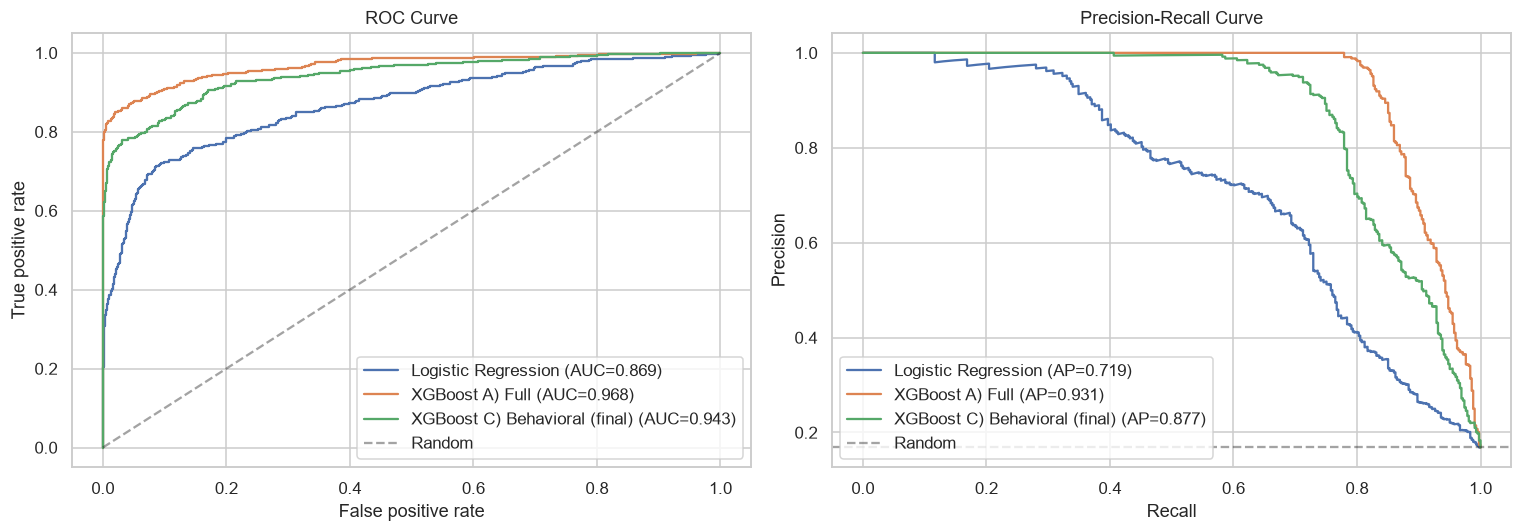

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for score, label in [(score_lr, "Logistic Regression"),
                     (score_full, "XGBoost A) Full"),
                     (score_strict, "XGBoost C) Behavioral (final)")]:
    fpr, tpr, _ = roc_curve(y_test, score)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={roc_auc_score(y_test, score):.3f})")

    prec, rec, _ = precision_recall_curve(y_test, score)
    axes[1].plot(rec, prec, label=f"{label} (AP={average_precision_score(y_test, score):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC Curve"); axes[0].legend(loc="lower right")

axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.4, label="Random")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

### 7.2 Which metric to prioritize in a real AML context

**PR-AUC over ROC-AUC.**

ROC-AUC incorporates the true negative rate in its computation. When the negative class dominates massively — in production AML, upwards of 99% of accounts are legitimate — ROC-AUC can remain high even where the model generates an unmanageable volume of false positives. PR-AUC ignores true negatives entirely and focuses exclusively on the quality of positive predictions, which is what consumes investigative resources.

A further distinction matters: **ROC-AUC has a fixed random baseline of 0.5, while the PR-AUC baseline equals the class prevalence.** On this dataset the random baseline is 0.168; at a realistic production prevalence of ~1% it would fall to 0.01. The same PR-AUC value therefore carries entirely different meaning across prevalence regimes, which is why PR-AUC must always be reported alongside its baseline.

On this dataset (16.85% positives) the divergence between the two metrics is less dramatic than it would be in production, but both are reported and PR-AUC is prioritized for consistency with the real-world scenario.

**However, the metric that governs a production monitoring system is Precision@K.**

Neither precision nor recall in isolation captures the binding operational constraint: **an analyst team can investigate a finite number of alerts per day.** A model with 0.99 recall that flags 80% of all accounts is useless — no team can review them.

The correct operational question is: *"If my team can investigate the top 5% riskiest accounts, how many genuine cases does it capture?"* That is Precision@K and Recall@K.

**On cost asymmetry:** a false negative — an account laundering money that goes undetected — implies regulatory exposure, fines and reputational risk. A false positive costs an analyst's time. This asymmetry justifies prioritizing recall — **but bounded by capacity**, not absolutely, since pure recall is trivially maximized by flagging everything.

In [12]:
def precision_at_k(y_true, score, k_pct):
    n = int(len(score) * k_pct)
    top_idx = np.argsort(score)[::-1][:n]
    captured = y_true.values[top_idx].sum()
    return {
        "K": f"Top {int(k_pct*100)}%",
        "Accounts reviewed": n,
        "SAR captured": int(captured),
        "Precision@K": captured / n,
        "Recall@K": captured / y_true.sum(),
    }


print("Final model — XGBoost C) Behavioral\n")
pak = pd.DataFrame([precision_at_k(y_test, score_strict, k) for k in [0.05, 0.10, 0.20, 0.30]])
print(pak.set_index("K").round(3))

print(f"\nTotal SAR accounts in the test set: {y_test.sum()}")
print(f"Base rate (precision of a random selection): {y_test.mean():.3f}")

Final model — XGBoost C) Behavioral

         Accounts reviewed  SAR captured  Precision@K  Recall@K
K                                                              
Top 5%                 125           125        1.000     0.297
Top 10%                250           247        0.988     0.587
Top 20%                500           341        0.682     0.810
Top 30%                750           381        0.508     0.905

Total SAR accounts in the test set: 421
Base rate (precision of a random selection): 0.168


**Operational reading:** this table translates the model into a business decision. The relevant question is not *"how good is the AUC?"* but *"how many genuine cases does my team find with the resources it has?"*. With capacity to investigate the **top 10%** of accounts, the behavioral model captures a substantial share of SAR cases at a precision far above the 16.85% base rate — the equivalent of a random selection.

The table also makes the trade-off explicit: expanding review capacity raises Recall@K (more laundering detected) while lowering Precision@K (more analyst time spent on legitimate accounts). This is the decision a compliance lead actually faces, and the model's role is to expose the frontier, not to make the choice.

**Note on the 0.5 threshold:** the precision, recall and F1 figures in Section 7.1 use the default threshold. In production that threshold would be calibrated explicitly against the investigative team's operational capacity rather than left at 0.5.

## 8. Interpretation with SHAP

SHAP (SHapley Additive exPlanations) decomposes each individual prediction into per-feature contributions. Unlike XGBoost's global feature importance — which only indicates which variables the model used most in aggregate — SHAP answers *why this specific account received this score*, a prerequisite for justifying a SAR filing to a regulator.

The **behavioral model (variant C)** is analyzed, whose features derive exclusively from observable transactional behavior.

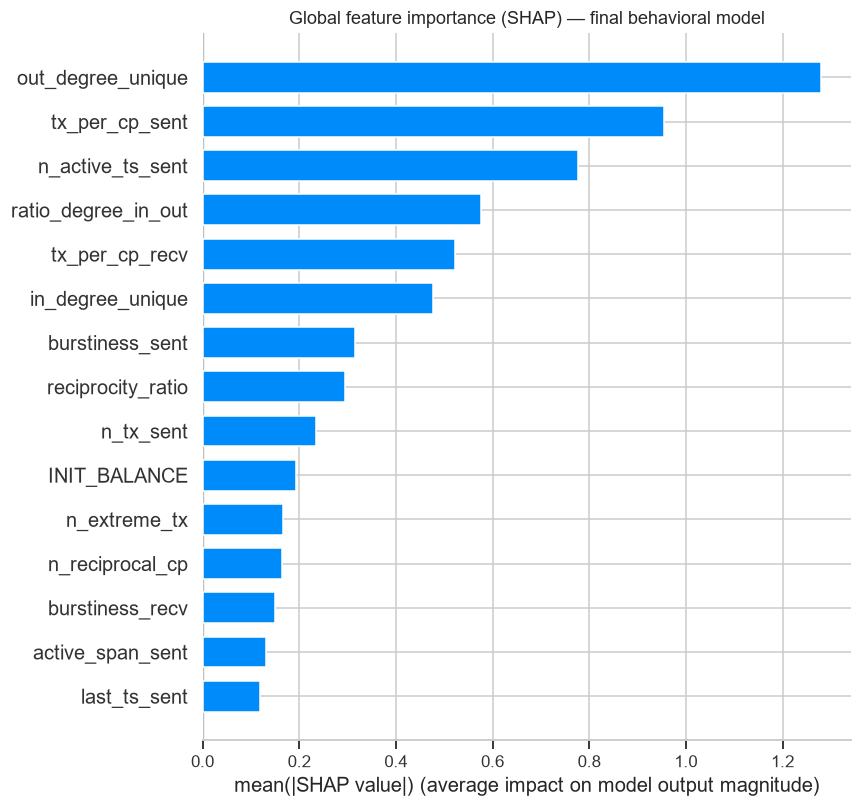

In [13]:
explainer = shap.TreeExplainer(xgb_strict)
shap_values = explainer.shap_values(X_test[cols_strict])

shap.summary_plot(shap_values, X_test[cols_strict], plot_type="bar", max_display=15, show=False)
plt.title("Global feature importance (SHAP) — final behavioral model")
plt.tight_layout()
plt.show()

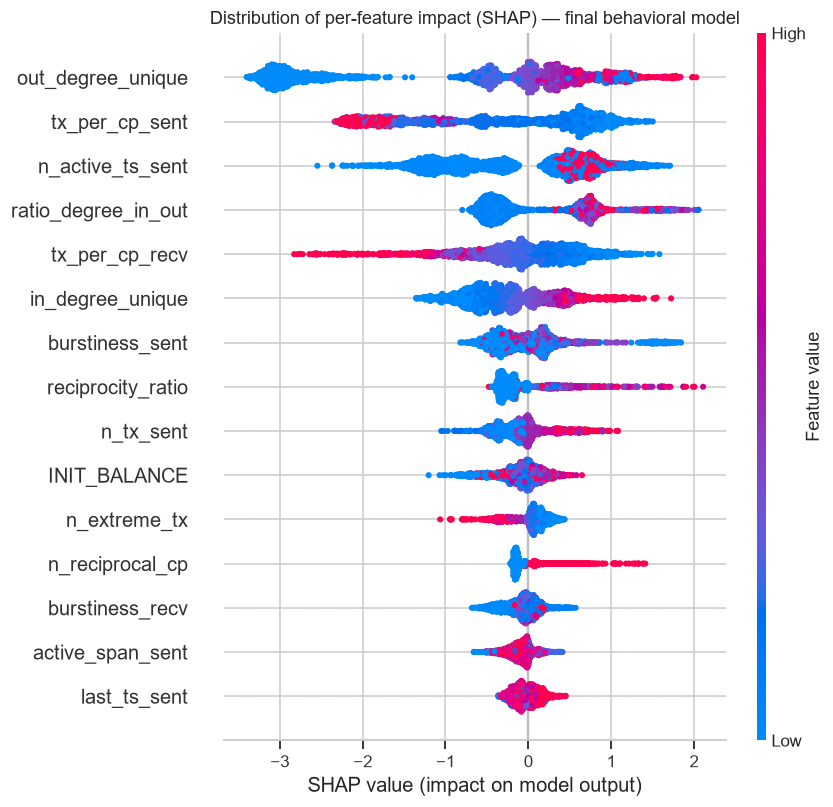

In [14]:
shap.summary_plot(shap_values, X_test[cols_strict], max_display=15, show=False)
plt.title("Distribution of per-feature impact (SHAP) — final behavioral model")
plt.tight_layout()
plt.show()

**Reading the beeswarm plot:** each point is one account. Horizontal position indicates how far that feature pushed the account's score toward *suspicious* (right) or *legitimate* (left). Colour indicates whether the feature's **value** for that account was high (red) or low (blue). The two axes are independent: position measures influence, colour measures the underlying value.

Their combination reveals the **direction of each relationship**:

- **`n_reciprocal_cp`** — high values (red) push right: more bidirectional counterparties increases risk. This is precisely the `cycle` signature the feature was designed to capture.
- **`tx_per_cp_sent`** — the relationship is inverted: high values (red) push left, low values push right. Repeating many transactions with the same counterparty *reduces* risk, whereas sending few transactions each to many distinct counterparties *increases* it — the structuring signature.
- **`n_extreme_tx`** — high values push left, and the band is narrow. The model effectively disregards it, confirming the caution flagged in notebook 02 (Section 5.4): its univariate correlation was mechanical rather than behavioral.

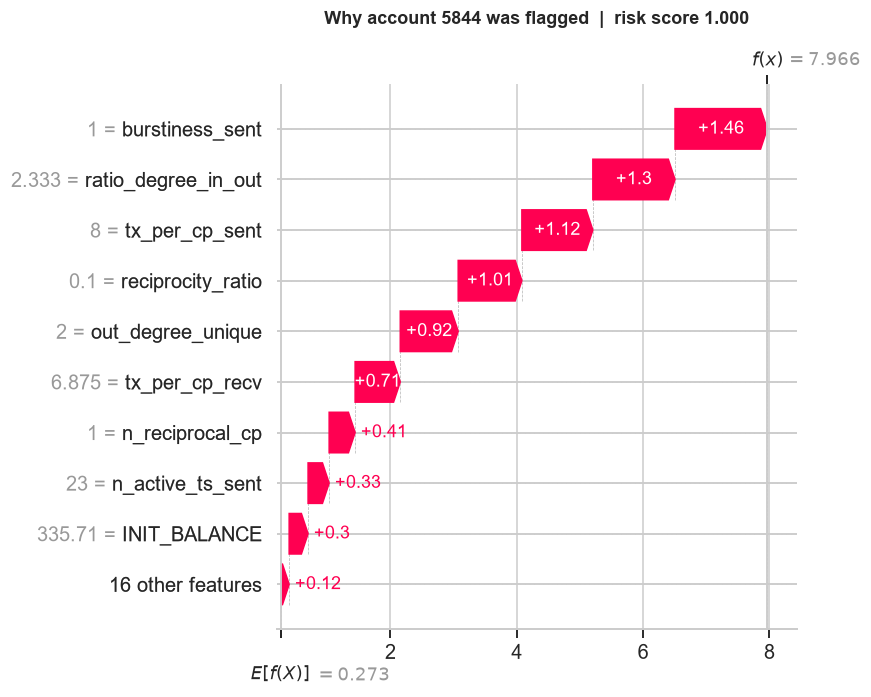

In [18]:
top_idx = int(np.argsort(score_strict)[::-1][0])
account_id = X_test.index[top_idx]

exp = shap.Explanation(
    values=shap_values[top_idx],
    base_values=explainer.expected_value,
    data=X_test[cols_strict].iloc[top_idx].values,
    feature_names=cols_strict,
)

plt.figure()
shap.plots.waterfall(exp, max_display=10, show=False)
plt.title(f"Why account {account_id} was flagged  |  risk score {score_strict[top_idx]:.3f}",
          fontsize=12, fontweight="bold", pad=18)

plt.tight_layout()
plt.savefig("slide16_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.1 Behaviors the model identifies

In the behavioral model, importance distributes across the structural families with no single feature dominating — an indication that the model combines multiple weak signals rather than relying on a shortcut:

| Family | Features | Typology captured |
|---|---|---|
| **Network degree** | `out_degree_unique`, `in_degree_unique` | `fan_in`: convergence of multiple distinct senders |
| **Flow** | `ratio_degree_in_out` | Directional imbalance: receives from many, sends to few |
| **Reciprocity** | `n_reciprocal_cp`, `reciprocity_ratio` | `cycle`: circularity, bidirectional counterparties |
| **Temporal** | `burstiness_sent`, `n_active_ts_sent` | Execution in concentrated bursts |
| **Repetition** | `tx_per_cp_sent`, `tx_per_cp_recv` | Structuring: many senders each contributing little |

This validates the feature engineering design hypothesis: the typologies present are **structural** patterns, and the features translating them into tabular form are the ones the model actually uses once deprived of shortcuts.

### 8.2 Individual prediction explanation

An example of the output a compliance analyst would receive when investigating an alert: the exact decomposition of why the model assigned that score.

In [15]:
# Highest-risk account in the test set
top_idx = np.argsort(score_strict)[::-1][0]
account_id = X_test.index[top_idx]

print(f"Account: {account_id}")
print(f"Risk score: {score_strict[top_idx]:.4f}")
print(f"True label: {'SUSPICIOUS' if y_test.loc[account_id] == 1 else 'legitimate'}\n")

contrib = pd.Series(shap_values[top_idx], index=cols_strict).sort_values(key=abs, ascending=False)
top_contrib = contrib.head(8)

detail = pd.DataFrame({
    "Feature value": X_test[cols_strict].loc[account_id, top_contrib.index],
    "SHAP contribution": top_contrib,
}).round(3)

print("Principal factors driving the score:")
print(detail)

Account: 5844
Risk score: 0.9997
True label: SUSPICIOUS

Principal factors driving the score:
                     Feature value  SHAP contribution
burstiness_sent              1.000              1.460
ratio_degree_in_out          2.333              1.301
tx_per_cp_sent               8.000              1.124
reciprocity_ratio            0.100              1.008
out_degree_unique            2.000              0.917
tx_per_cp_recv               6.875              0.715
n_reciprocal_cp              1.000              0.411
n_active_ts_sent            23.000              0.334


## 9. Conclusions, limitations and next steps

### 9.1 Which model performed best?

**XGBoost outperforms logistic regression by a wide margin across all configurations.** The result confirms the hypothesis advanced in the EDA: given that no isolated feature exceeds 0.30 correlation with the target and the classes overlap substantially in two-dimensional space, the signal resides in **conditional combinations** of behaviors. Logistic regression, constrained to a linear decision boundary, cannot represent them; XGBoost captures them natively through cascading splits.

**The final model is XGBoost variant C (behavioral)** — not variant A, despite its nominally superior metrics. The difference between them does not represent greater predictive capability but rather exploitation of generator-side information that would not exist in production.

### 9.2 Most important features

In the behavioral model the structural families dominate: network degree (`out_degree_unique`, `in_degree_unique`), directional flow (`ratio_degree_in_out`), reciprocity (`n_reciprocal_cp`, `reciprocity_ratio`) and temporal concentration (`burstiness_sent`, `n_active_ts_sent`). No single feature dominates in isolation, indicating that the model combines weak signals — the expected behavior in a genuine AML problem.

**A relevant finding about the process itself:** in variants A and B the dominant features were `amt_sent_std` (amount magnitude) and `TX_BEHAVIOR_ID` (generator parameter) respectively. Only after removing both sources of non-behavioral information did network structure emerge as the model's foundation. Feature-importance diagnostics were therefore the instrument that revealed the model was taking shortcuts.

### 9.3 Behaviors identified

- **Flow convergence (`fan_in`):** accounts receiving from an abnormally high number of *distinct* counterparties, with small amounts per sender — the structuring signature.
- **Circularity (`cycle`):** accounts with an elevated proportion of bidirectional counterparties, a pattern uncommon in legitimate commercial flow.
- **Burst execution:** activity concentrated within few timesteps rather than distributed evenly.

### 9.4 Principal limitations

**1. Generator artifact in transaction amounts.** The central finding of this notebook: the amounts of transactions injected by AMLSim (\$2.54–\$19.92) do not overlap with the general distribution, allowing a trivial rule — flag any account that sent a transaction below \$20 — to achieve 90% recall. The metrics of any model using amount magnitudes on this dataset are inflated and not extrapolable to production.

**2. `TX_BEHAVIOR_ID` as a generator parameter.** Although informative, the variable is not an observation of behavior but a parameter AMLSim used to *generate* that behavior — and the same process determined which accounts would be fraudulent. It was excluded from the final model. The ablation demonstrated that its contribution, while dominant in importance, was redundant: other features carry the same information.

**3. Unrepresentative class imbalance.** The 16.85% SAR rate is far above production rates (typically <1%). Real performance on a dataset with the correct prevalence would be considerably lower, particularly in precision.

**4. Limited typological coverage.** Only `cycle` and `fan_in`. The model has not been exposed to `fan_out`, `scatter-gather`, `stack`, or to schemes involving cash, and there is no guarantee it generalizes to them.

**5. Single channel.** All transactions are transfers. No cash deposits or withdrawals — material channels in real AML.

**6. Observation window censoring.** As documented in the EDA (6.3), ~5% of schemes appear truncated at the temporal boundaries. The model trains on partial evidence in those cases.

**7. Uncalibrated decision threshold.** The precision, recall and F1 metrics use the default 0.5 threshold. In production this should be calibrated against the investigative team's operational capacity.

### 9.5 What would be improved with more time

1. **Validate on a dataset with realistic prevalence.** Downsample the positive class to ~1% and re-evaluate. This is the test that would best approximate production performance.

2. **Second-order graph features.** Current features are local (node degree, reciprocity). Metrics such as PageRank, betweenness centrality, or community detection would capture the account's position within the complete network rather than only its immediate neighborhood.

3. **Graph Neural Networks.** The current model consumes a *tabular translation* of graph structure. A GNN would learn directly from the topology, capturing patterns that manual aggregations do not anticipate.

4. **Threshold calibration by operational capacity.** Fix K according to the alert volume the investigative team can process, and optimize the model for Precision@K rather than for a global metric.

5. **Temporal split.** Train on earlier periods and evaluate on later ones, replicating deployment conditions and enabling detection of data drift.

6. **Production drift monitoring.** The winsorization threshold and feature distributions are fixed at training time. A real system requires continuous monitoring and scheduled retraining as distributions shift.

7. **LLM-assisted analyst workflows.** Generating automated SAR narratives from SHAP explanations — translating per-feature contributions into natural language for the compliance analyst.

In [16]:
# Export of per-account risk scores
risk_scores = pd.DataFrame({
    "ACCOUNT_ID": X_test.index,
    "risk_score_logreg": score_lr,
    "risk_score_xgb_full": score_full,
    "risk_score_xgb_behavioral": score_strict,
    "IS_FRAUD_true": y_test.values,
}).sort_values("risk_score_xgb_behavioral", ascending=False)

risk_scores.to_csv("data_processed/risk_scores_test.csv", index=False)

print("Exported: data_processed/risk_scores_test.csv")
print("\nTop 10 highest-risk accounts (final behavioral model):")
print(risk_scores.head(10).to_string(index=False))

Exported: data_processed/risk_scores_test.csv

Top 10 highest-risk accounts (final behavioral model):
 ACCOUNT_ID  risk_score_logreg  risk_score_xgb_full  risk_score_xgb_behavioral  IS_FRAUD_true
       5844           0.938562             0.999876                   0.999653              1
       2627           0.926300             0.999956                   0.999639              1
       5677           0.955972             0.999904                   0.999450              1
       9999           1.000000             0.999242                   0.999196              1
       8571           1.000000             0.999853                   0.999076              1
       7425           0.996873             0.998937                   0.999067              1
       6089           0.998065             0.999861                   0.998996              1
       8786           0.937699             0.999421                   0.998958              1
       7513           0.997748             0.999759 